In [1]:
%matplotlib widget

## Exercise No. 6 -- Outgoing Longwave Radiation (OLR)

#### 1)

Run ARTS on the Jupyter notebook olr.ipynb . This will calculate the spectrum
of outgoing longwave radiation for a midlatitude-summer atmosphere.
Our calculation trades accuracy for computational efficiency. For
example, we use only water vapor and carbon dioxide as absorbers.
We use only 300 frequency grid points and approximately 54,000 spectral
lines, whereas for accurate calculations one needs at least 10,000
frequency grid points and 500,000 spectral lines, taking into account
absorbing species like ozone and methane. The script plots the spectral
irradiance, in SI units, as a function of wavenumber. Planck curves
for different temperatures are shown for comparison. We integrate
the whole spectrum to quantify the power per square that is emitted
by the atmosphere (value in title).

* How would the OLR spectrum look in units of brightness temperature?
* How would the Planck curves look in units of brightness temperature?
* Find the $\text{CO}_{2}$ absorption band and the regions of $\text{H}_{2}\text{O}$ 
absorption. From which height in the atmosphere does the radiation in the $\text{CO}_{2}$ band originate?
* Are there window regions?
* What will determine the OLR in the window regions?
* Use the plot to explain the atmospheric greenhouse effect.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from pyarts import xml
from pyarts.arts import convert
from olr_module import calc_olr_from_atmfield, Change_T_with_RH_const, cmap2rgba, planck

os.makedirs("plots", exist_ok=True)

In [21]:
# Read input atmosphere
atmfield = xml.load("input/midlatitude-summer.xml")
atmfield = xml.load("input/tropical.xml")

# Scale the CO2 concentration
atmfield.scale("abs_species-CO2", 1)

# Add a constant value to the temperature
atmfield.set("T", atmfield.get("T") + 0)

# Add a constant value to the temperature but 
# without changing relative humidity 
atmfield = Change_T_with_RH_const(atmfield,DeltaT=0)

# Calculate the outgoing-longwave radiation
f, olr = calc_olr_from_atmfield(atmfield, verbosity=0)
fall = f 

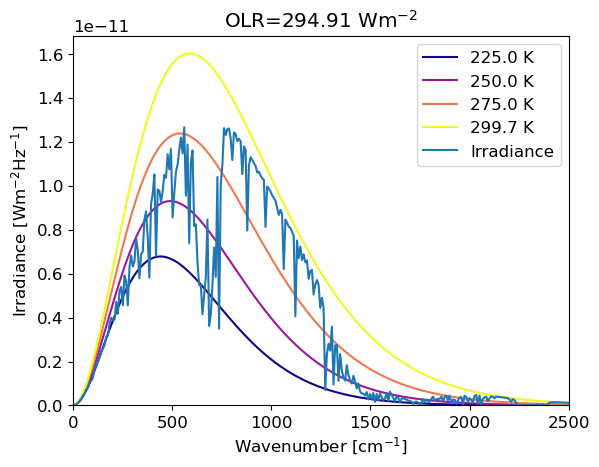

In [3]:
# Plotting.
import matplotlib
font = {'size'   : 12}
matplotlib.rc('font', **font)

wn = convert.freq2kaycm(f)

temps = [225, 250, 275, atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wn, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wn, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wn.min(), wn.max())
ax.set_xlabel(r"Wavenumber [$\sf cm^{-1}$]")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalolr.pdf")

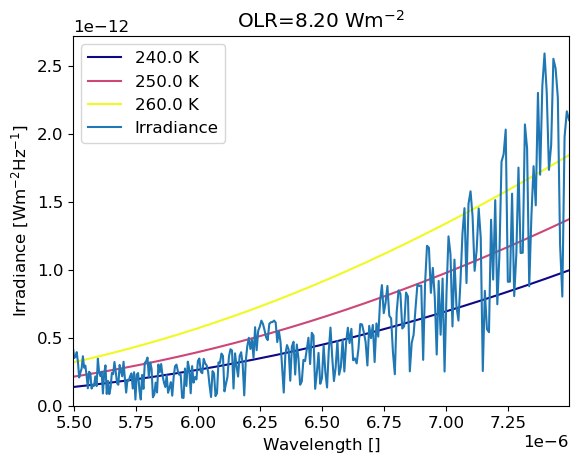

In [4]:
# Plotting for my frequency range: WV channels 
#f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
#f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
#f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

f, olr = calc_olr_from_atmfield(atmfield, verbosity=3, fmin=3e8/ 7.5e-6, fmax=3e8/ 5.5e-6) # 5-8 microns 

wn = convert.freq2kaycm(f)
wl = convert.freq2wavelen(f)

temps = [240, 250, 260] # surface T , atmfield.get("T", keep_dims=False)[0]]
temp_colors = cmap2rgba("plasma", len(temps))

fig, ax = plt.subplots()
for t, color in sorted(zip(temps, temp_colors)):
    ax.plot(
        wl, np.pi * planck(f, t), label=f"{t:3.1f} K", color=color
    )
ax.plot(wl, olr, color="C0", label="Irradiance")
ax.legend()
ax.set_title(rf"OLR={np.trapezoid(olr, f):3.2f} $\sf Wm^{{-2}}$")
ax.set_xlim(wl.min(), wl.max())
ax.set_xlabel(r"Wavelength [$\sf $]")
ax.set_ylabel(r"Irradiance [$\sf Wm^{-2}Hz^{-1}$]")
ax.set_ylim(bottom=0)
fig.savefig("plots/tropicalWVolr.pdf")

In [5]:
# Channel TB from OLR integral over that band 
def TB_from_olr(f,olr):
    temps = np.arange(200,320,1)  # a range of plausible temperatures (K) to interpolate linearly among
    FBs = []                      # Blackbody fluxes corresponding to above 
    for t in temps:
        FBs.append( np.trapezoid(np.pi * planck(f, t), f) )

    myF = np.trapezoid(olr, f)
    TB_interp = np.interp(myF, FBs, temps)
    
    return TB_interp

In [18]:
# test with above spectrum 241.6654609921063 248.8933227778732 260.0744514335408
TB_from_olr(f8,olr8)

np.float64(239.21150827295446)

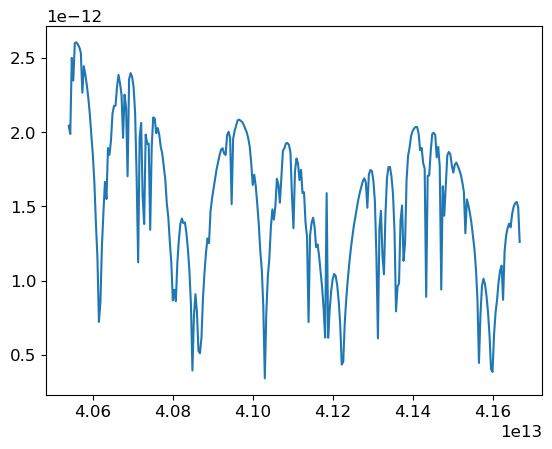

In [14]:
plt.plot( f10, olr10);

In [89]:
# Expressing WV channel fluxes AS TB, compare to MY_rtcalc results for midlat summer

# Copy wavelengths from MYrtcalc notebook where I worked it all out
#f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
#f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
#f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

atmfield = xml.load("input/midlatitude-summer.xml")

f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 

In [90]:
# Compare to midlat summer from MY_rtcalc 241.6654609921063 248.8933227778732 260.0744514335408
T8 = TB_from_olr(f8, olr8)
T9 = TB_from_olr(f9, olr9)
T10= TB_from_olr(f10,olr10)

T8,T9,T10

(np.float64(237.86409387038077),
 np.float64(245.6326359767404),
 np.float64(256.71398373465104))

-------------------
# Ready to perturb! 
from olr_module.py: 

    vmr = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

That shape is (1, 46, 1, 1)

    # update atmosphere field
    atmfield.set("T", T + DeltaT)
    atmfield.set("abs_species-H2O", vmr)
    

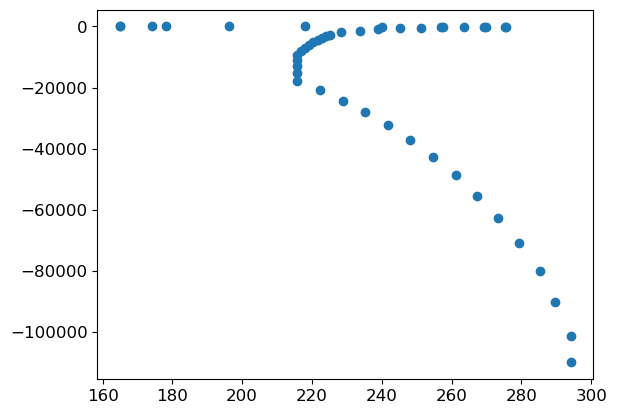

In [79]:
q = atmfield.get("abs_species-H2O")
T = atmfield.get("T")
p = atmfield.grids[1][:].reshape(T.shape)

plt.scatter( np.squeeze(T), -np.squeeze(p) );

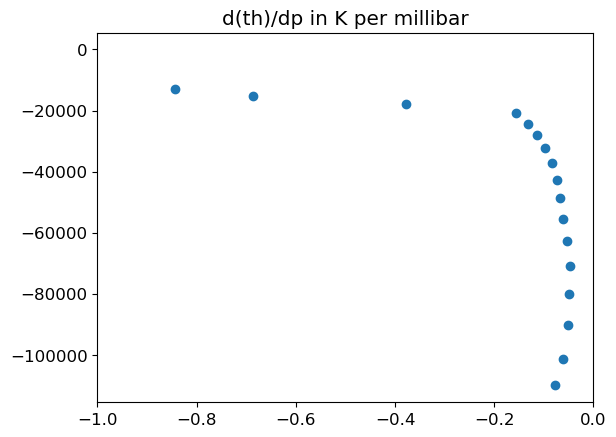

In [88]:
# Construct a potential temperature and its derivative 
# d(th)/dp <0, yes checked

th= T * ((100000./(p))**(287./1004))
dthdp = np.gradient(np.squeeze(th))/np.gradient(np.squeeze(p))

plt.scatter( dthdp*100, -np.squeeze(p) )
plt.xlim([-1,0])
plt.title('d(th)/dp in K per millibar');

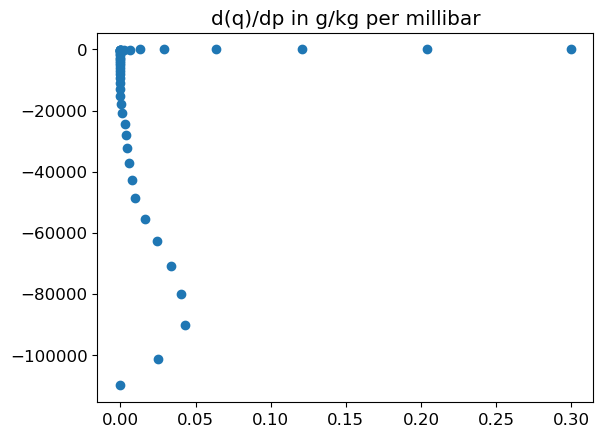

In [77]:
dqdp = np.gradient(np.squeeze(q))/np.gradient(np.squeeze(p))

plt.scatter( dqdp*100*1000, -np.squeeze(p) )
plt.title('d(q)/dp in g/kg per millibar');

In [98]:
# Consider TB change due to local perturbations to T and q, each scaled to vertical displacements of 1mb

# Container for results 
DT8s_th = []
DT8s_q  = []
DT8s_bo = [] 
DT9s_th = []
DT9s_q  = []
DT9s_bo = [] 
DT10s_th = []
DT10s_q  = []
DT10s_bo = [] 


for ilev in np.arange(1,23): 
    print(ilev) 
    atmfield = xml.load("input/midlatitude-summer.xml")  # RESET TO ORIGINAL PROFILE
    q = atmfield.get("abs_species-H2O")
    T = atmfield.get("T")
    p = atmfield.grids[1][:].reshape(T.shape)

    dq =  dqdp[ilev] * 100. # a 1mb vertial displacement locally in this layer 
    dth= dthdp[ilev] * 100.  
    dT = dth * T[0,ilev,0,0]/th[0,ilev,0,0]  # convert to T units 

# T pert alone first; can add to T since it will be overwritten next time thru loop 
    T[0,ilev,0,0] += dT
    atmfield.set("T", T)
    
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_th.append(T8p - T8)
    DT9s_th.append(T9p - T9)
    DT10s_th.append(T10p - T10)

# Next, Both T and q perts 
    q[0,ilev,0,0] += dq
    atmfield.set("abs_species-H2O", q)

    atmfield.set("abs_species-H2O", q+dq)
    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_bo.append(T8p - T8)
    DT9s_bo.append(T9p - T9)
    DT10s_bo.append(T10p - T10)

# Finally, q pert alone, subtracting T pert which had been added above   
    T[0,ilev,0,0] -= dT
    atmfield.set("T", T)

    f8, olr8 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6) # ch8, 5.75-6.6 microns
    f9, olr9 = calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.70e-6) # ch9,  
    f10,olr10= calc_olr_from_atmfield(atmfield, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.20e-6) # ch10, 
    
    T8p = TB_from_olr(f8, olr8)
    T9p = TB_from_olr(f9, olr9)
    T10p= TB_from_olr(f10,olr10)

    DT8s_q.append(T8p - T8)
    DT9s_q.append(T9p - T9)
    DT10s_q.append(T10p - T10)
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


In [102]:
paxis = p[0,1:23,0,0]/100
paxis

array([1013. ,  902. ,  802. ,  710. ,  628. ,  554. ,  487. ,  426. ,
        372. ,  324. ,  281. ,  243. ,  209. ,  179. ,  153. ,  130. ,
        111. ,   95. ,   81.2,   69.5,   59.5,   51. ])

Text(0.5, 1.0, 'TB9 change from local vertical displacement of -1mb')

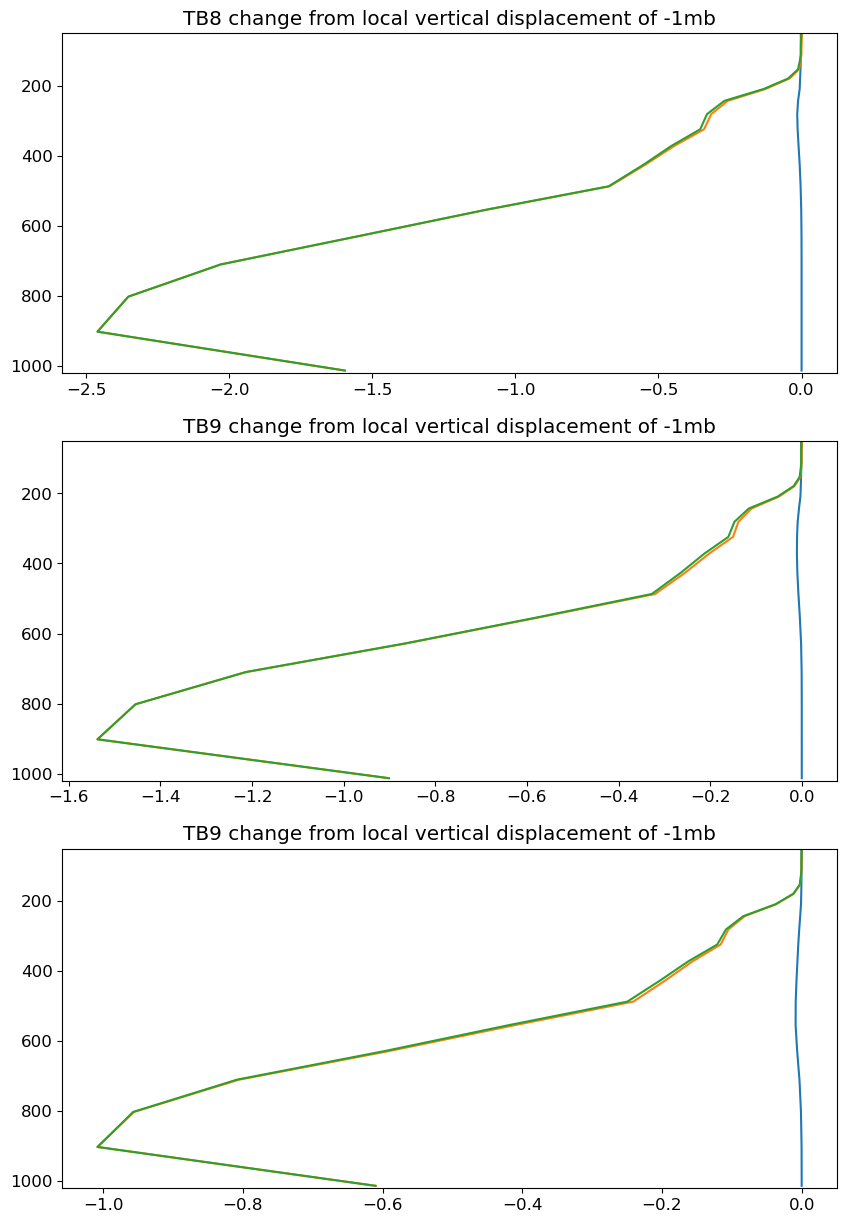

In [114]:
plt.figure(figsize=(10,15))

plt.subplot(311)
plt.plot(DT8s_th, paxis)
plt.plot(DT8s_q, paxis)
plt.plot(DT8s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB8 change from local vertical displacement of -1mb')

plt.subplot(312)
plt.plot(DT9s_th, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT9s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB9 change from local vertical displacement of -1mb')

plt.subplot(313)
plt.plot(DT10s_th, paxis)
plt.plot(DT10s_q, paxis)
plt.plot(DT10s_bo, paxis)
plt.ylim([1020,50]);
plt.title('TB9 change from local vertical displacement of -1mb')


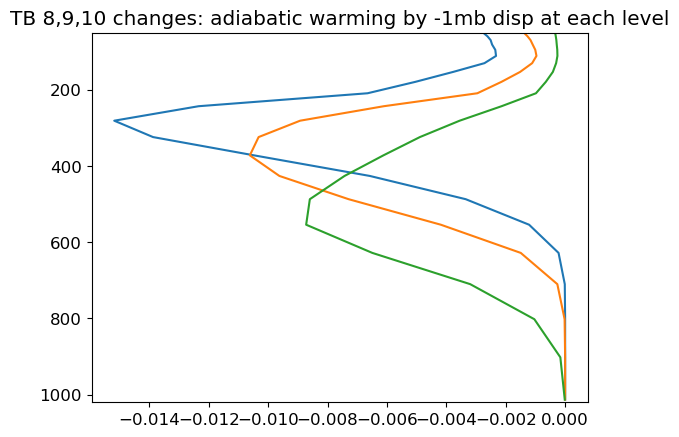

In [115]:
plt.plot(DT8s_th, paxis)
plt.plot(DT9s_th, paxis)
plt.plot(DT10s_th, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: adiabatic warming by -1mb disp at each level');

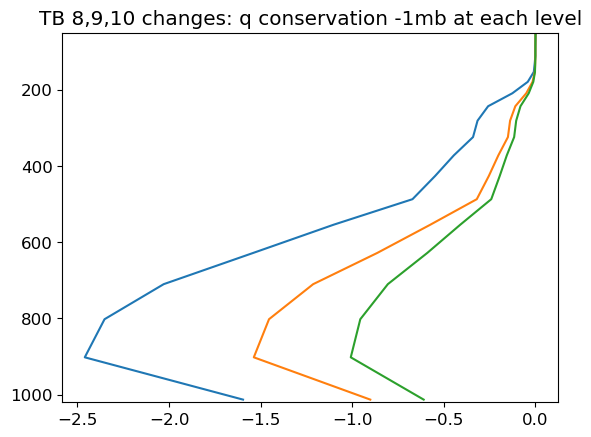

In [116]:
plt.plot(DT8s_q, paxis)
plt.plot(DT9s_q, paxis)
plt.plot(DT10s_q, paxis);
plt.ylim([1020,50]);
plt.title('TB 8,9,10 changes: q conservation -1mb at each level');

#### 2) 

Investigate how the OLR changes for different atmospheric conditions
by modifying the input data.  
Use `atmfield.scale(...)`,
`atmfield.set(...)` and `Change_T_with_RH_const(...)` to change the atmospheric data:

* Add $1\,\,\text{K}$ to the temperature.
* Add $1\,\,\text{K}$ to the temperature but hold relative humidity constant.
* Increase the $\text{CO}_{2}$ conentration by a factor of $2$.
* Increase the $\text{H}_{2}\text{O}$ conentration by a factor of $1.2$.
   
1) Change it, and calculate and plot the spectrum for each change. 
2) Compare the spectra of the changed atmosphere with the unchanged OLR spectrum. Where
   do the changes occur? Explain the differnt effects of the changed atmospheres.
3) Compare the OLR numbers, which is the more potent greenhouse gas,
$\text{CO}_{2}$ or $\text{H}_{2}\text{O}$?

In [65]:
plt.close()